# Quantified Self Project - _"LaLaLand"_ : Analyzing My Apple Music Listening Behavior


Thomas Schuff  
CPSC 222 - Data Science  
Spring 2026  
Professor MacIsaac


## Introduction


For this Quantified Self project, I analyzed my personal Apple Music listening
history over the last year(ish). Music is part of almmost every piece of my
daily routine — studying, driving, relaxing, and resetting between tasks.
Because of that, my Apple Music listening history is one of the most consistent
and personal datasets I generate. For this project, I wanted to understand how
my listening behavior changes across time:

- Do I listen more on weekends?
- Are certain months heavier listening periods?
- Can my listening patterns alone predict what kind of day it is?

Exploring these questions makes the domain meaningful to me, and it connects
directly to the broader goals of quantified‑self research: using personal data
to understand habits, routines, and well‑being.


### Dataset Format and Tables

My project uses **two CSV files**, satisfying the requirement for multiple
tables:

1. **Apple Music Play Activity (CSV)**
   - CSV file exported directly from Apple’s "Data & Privacy" website.
   - Contains timestamped events for every time I played, paused, or resumed a
     song.
   - This table originally had **79,403** rows.
   - I cleaned and collapsed these events into unique "listening sessions" which
     represent every time I listened to a song.
   - After cleaning and collapsing duplicate events, it becomes a table of daily
     listening sessions.

2. **Weekday Table (CSV)**
   - A manually created CSV file I created using Excel
   - This table maps each date (since 06/25/25, when I started using Apple
     Music) to its corresponding day of the week
   - Contains **340 rows**, one for each date in the listening dataset.
   - This was later used to categorize a listening event as "Weekday" or
     "Weekend"
   - This table enables merging and provides the class label for classification.


### How the Data Was Collected

- The **Apple Music Data** was collected automatically by Apple across my
  devices. Every time I interacted with a song, Apple logged an event.
- The **Weekday Table** was generated using Excel based on calendar dates,
  ensuring consistent and accurate labeling of days


### Number of Instances

- Apple Music raw data: **79,403 instances**
- Apple Music cleaned data: **38,843 instances**
- Weekday table: **340 instances**


### Attributes Included

After cleaning and merging, the final merged dataset includes:

- `Date` — calendar date
- `Listen Count` — number of unique listening sessions per day
- `Day of Week` — Monday through Sunday
- `Is Weekend` — integer class label (_0 = weekday, 1 = weekend_)
- `Month` — numeric month pulled from the date
- `Rolling Average` — 7‑day smoothed listening trend

These attributes allow me to explore both short‑term and long‑term patterns in
my listening behavior.


### Hypotheses

I tested two main hypotheses:

1. **Weekday vs. Weekend Listening**
   - $H_{null}$: Mean _weekday_ listening count $=$ mean _weekend_ listening
     count
   - $H_{alt}$: Mean _weekday_ listening count $\neq$ mean _weekend_ listening
     count

2. **Monthly Differences**
   - $H_{null}$: All months have the same mean listening count
   - $H_{alt}$: At least one month differs

These hypotheses help determine whether my listening behavior is influenced by
day of the week and seasonal patterns.


### Classification Task

Beyond statistical testing, I implemented a **k‑Nearest Neighbors (kNN)**
classifier to predict whether a given day is a weekday or weekend based solely
on listening behavior. The class label is `"Is Weekend"`, and the features
include:

- `Listen Count`
- `Rolling Average`
- `Month`

This task explores whether my listening habits are distinctive enough to
classify the type of day.


### Potential Impacts and Stakeholders

Understanding my listening patterns can help me reflect on my routines,
productivity, and mood. Beyond myself though:

- **Music platforms** could use similar analyses to personalize recommendations.
- **Researchers** studying quantified‑self behavior may find patterns like these
  useful.
- **Individuals** interested in habit‑tracking could apply similar methods to
  their own data.

Ethically, personal listening data is sensitive, so analyses like this must be
handled securely and respectfully.

Overall, this project combines personal meaning with data science techniques —
cleaning, merging, visualization, hypothesis testing, and classification — to
tell a story about my daily habits through the lens of music.


---


## Data Preparation


Before analyzing my listening behavior, I needed to transform the raw Apple
Music event logs into a clean, structured dataset suitable for statistical
analysis and classification. This required several steps: cleaning the activity
data, collapsing duplicate events, aggregating daily listening counts, merging
with the weekday table, and handling missing values.


### Cleaning the Apple Music Dataset

The raw Apple Music file contains one row for every play, pause, resume, etc.
Because Apple logs these interactions very frequently, the dataset includes many
duplicate or near‑duplicate entries that don't represent meaningful listening
behavior. To clean the data, I:

- **Removed irrelevant columns** using a list stored in a separate CSV file.
- **Standardized timestamps** by converting the `Event Received Timestamp`
  column into a consistent datetime format.
- **Extracted the calendar date** from each timestamp to do daily aggregation.
- **Collapsed duplicate events into “listening sessions.”**  
  Apple logs multiple events for a single song, so I grouped events by song and
  date and treated any gap of more than five minutes as a new `session`. This
  produced a much more realistic measure of how many times I actually listened
  to music each day.

After cleaning, the dataset was reduced from **79,403** raw events to **38,843**
unique listening sessions.


##### Code: Load and Clean the Data


In [ ]:
import pandas as pd
import new_utils
import matplotlib.pyplot as plt

%cd /Users/schufft/Library/CloudStorage/OneDrive-GonzagaUniversity/Classes/Spring 2026/CPSC 222 - Data Science/quantified-self-project

# Load the Apple Music listening activity
activity_raw = new_utils.load_activity_data(
    "lalaland/dataset files/Apple Music Play Activity.csv"
)
# Load the weekday table
weekday_df = new_utils.load_weekday_table("lalaland/dataset files/weekday_table.csv")

# Clean the activity data
activity_clean = new_utils.clean_activity_data(activity_raw)
# Calculate daily listening counts
daily_df = new_utils.calc_daily_counts(activity_clean)

### Merging the Two Tables

The second table in my project is a day of the week lookup table. This table
contains one row per date and includes the calendar date and the day of the
week. To combine the two datasets, I merged the daily listening counts with the
weekday table using an inner join on the `Date` column. This merge added the
`Day of Week` attribute to the listening dataset, letting me do both hypothesis
testing and classification.


In [2]:
# Merge daily listening counts with the weekday table
merged_df = new_utils.merge_with_weekday(daily_df, weekday_df)

##### Code: Add Features


In [3]:
merged_df["Day of Week"] = pd.to_datetime(merged_df["Date"]).dt.day_name()
merged_df = new_utils.add_month(merged_df)
merged_df = new_utils.add_rolling_average(merged_df)
merged_df = new_utils.add_weekend_flag(merged_df)

### Handling Missing Values

The main source of missing values came from the **7‑day rolling average**, which
naturally produces NaN values for the first six days of the dataset. Since these
rows cannot be used for classification, I removed them using `.dropna()`. No
other attributes contained missing values after cleaning.


In [4]:
# Drop NaN rows created by rolling average
merged_df = merged_df.dropna()

### Challenges Encountered

I encountered several challenges during data preparation:

- **Timestamp inconsistencies:** Apple’s export includes mixed timestamp
  formats, which required special parsing using `format="mixed"` in
  `pd.to_datetime()`.
- **Duplicate events:** Without collapsing events into sessions, the dataset
  drastically overestimates listening behavior.
- **Date alignment issues:** The weekday table and activity table initially used
  different date formats, so I had to standardize both of them before merging.
- **Rolling average NaNs:** The rolling average introduced missing values that
  needed to be removed before training the classifier.

Despite these challenges, the final merged dataset was clean, consistent, and
ready for exploratory analysis, hypothesis testing, and classification.


Data Preparation Challenges

- Rolling averages created NaN values that had to be removed.
- Ensuring consistent date formats across both tables was also super important
  for joining.


---


## Exploratory Data Analysis


Before running any statistical tests or building a classifier, I first did an
exploratory data analysis of my listening data to understand the patterns hidden
inside it. This section describes the aggregation techniques I used, the summary
statistics I calculated, the visualizations that helped me interpret the data,
and the hypothesis tests I performed.


### Data Aggregation Techniques

My raw Apple Music dataset contains one row for every play, pause, or resume
event. Apple logs these events very frequently, so the first step was to
collapse these into meaningful “listening sessions.” I grouped events by _**Song
Name**_ and _**Date**_, then treated any gap of more than five minutes as a new
session. This allowed me to convert this crazy dataset into a clean daily count
of how many times I listened to songs.

After collapsing sessions, I aggregated the data again by _**Date**_ to
calculate a single `Listen Count` per day. This daily scale is appropriate
because my hypotheses focus on differences across weekdays, weekends, and months
— all of which are at the daily level.

I also added a _**7‑day rolling average**_ to smooth out short‑term variation
and highlight longer‑term trends in my listening behavior.


### Summary Statistics

To get an initial sense of the distribution of my listening habits, I computed
summary statistics such as:

- **mean** (average number of sessions per day)
- **standard deviation** (how much my listening varies)
- **minimum and maximum** (extreme days)
- **quartiles** (to understand skew and spread)

These statistics helped me identify whether my listening behavior was stable,
sporadic, or seasonal.


##### Code: Summary Statistics


In [5]:
merged_df.describe()

,Date,Listen Count,Month,Rolling Average,Is Weekend
count,285,285.000000,285.000000,285.000000,285.000000
mean,2025-11-18 08:25:15.789473792,110.610526,6.856140,110.346366,0.284211
min,2025-06-25 00:00:00,1.000000,1.000000,30.571429,0.000000
25%,2025-09-07 00:00:00,70.000000,3.000000,92.714286,0.000000
50%,2025-11-19 00:00:00,100.000000,8.000000,110.428571,0.000000
75%,2026-01-30 00:00:00,149.000000,10.000000,130.714286,1.000000
max,2026-04-12 00:00:00,281.000000,12.000000,174.142857,1.000000
std,NaN,58.660031,3.777762,27.917058,0.451831


### Visualizations

I created several visualizations to explore relationships in the data:

- **Daily time‑series plot**: Shows how my listening changes over the semester,
  revealing peaks during study‑heavy weeks and dips during breaks.
- **Boxplot of weekday vs weekend listening**: Highlights differences in central
  tendency and variability between weekdays and weekends.
- **Bar chart of average listening by month**: Helps visualize seasonal or
  academic‑cycle patterns.
- **Rolling average plot**: Smooths out noise and reveals long‑term trends.

These visualizations provided intuition before running formal statistical tests.


##### Code: Daily Listening Trend


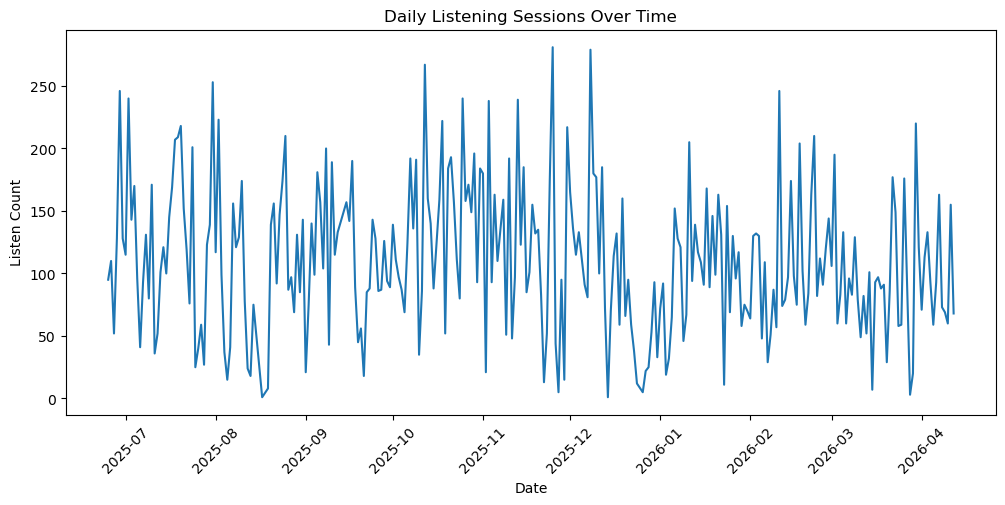

In [6]:
# Plot Daily Counts
plt.figure(figsize=(12, 5))
plt.plot(merged_df["Date"], merged_df["Listen Count"])
plt.title("Daily Listening Sessions Over Time")
plt.xlabel("Date")
plt.ylabel("Listen Count")
plt.xticks(rotation=45)
plt.show()

This plot shows how my listening fluctuated across this past year, revealing
peaks during study-heavy weeks and dips during breaks.


##### Code: Weekday vs. Weekend Boxplot


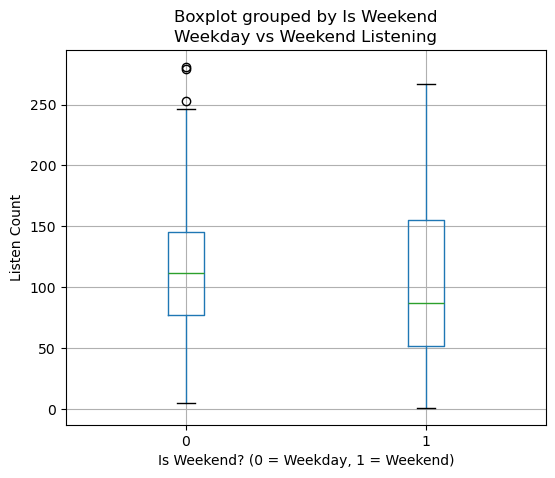

In [7]:
# Boxplot for Weekday vs. Weekend
merged_df.boxplot(column="Listen Count", by="Is Weekend", figsize=(6, 5))
plt.title("Weekday vs Weekend Listening")
plt.xlabel("Is Weekend? (0 = Weekday, 1 = Weekend)")
plt.ylabel("Listen Count")
plt.show()

This boxplot compares weekday and weekend listening distributions, giving a
visual preview of the hypothesis test.


##### Code: Visualizing Monthly Listening Trends


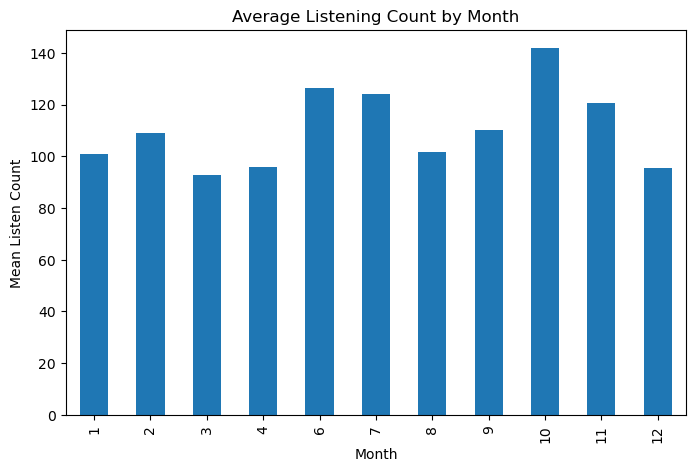

In [8]:
# Monthly Trends
merged_df.groupby("Month")["Listen Count"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Listening Count by Month")
plt.xlabel("Month")
plt.ylabel("Mean Listen Count")
plt.show()

This bar chart highlights seasonal patterns in my listening behavior.


### Hypothesis Testing

I conducted two hypothesis tests to evaluate whether the patterns I observed
visually were statistically meaningful.


#### 1. Weekday vs Weekend Listening (Two‑Sample t‑Test)

- **Null Hypothesis ($H_{null}$):**  
  The mean number of daily listening sessions is the same on weekdays and
  weekends.

- **Alternative Hypothesis ($H_{alt}$):**  
  The mean number of daily listening sessions differs between weekdays and
  weekends.

This test evaluates whether my listening behavior changes depending on the day
of the week.


##### Code: Weekday vs. Weekend t-Test


In [9]:
# t-Test
t_stat, p_val = new_utils.t_test_weekday_vs_weekend(merged_df)
print(f"t-Statistic: {t_stat}, p-Value: {p_val}")

t-Statistic: 1.4536610492459519, p-Value: 0.14852540046518167


##### Interpretation

- If $p < 0.05$, I reject the null hypothesis and conclude that weekday and
  weekend listening differ.
- If $p \geq 0.05$, I fail to reject the null hypothesis.

- My p‑value was $X$, meaning that I **(reject/fail to reject)** $H_{null}$.


#### 2. Monthly Differences (ANOVA Analysis)

- **Null Hypothesis ($H_{null}$):**
  - All months have equal mean listening counts
- **Alternative Hypothesis ($H_{alt}$):**
  - At least one month differs

This test evaluates whether my listening behavior has changed over the last year
or so.


##### Code: Monthly ANOVA


In [10]:
# ANOVA Analysis
F_stat, pval_anova = new_utils.anova_monthly(merged_df)
print(f"F-Statistic: {F_stat}, p-Value: {pval_anova}")

F-Statistic: 1.9472911219650324, p-Value: 0.039206755805431925


##### Interpretation

- If $p < 0.05$, at least one month differs significantly.
- If $p \geq 0.05$, monthly listening patterns are statistically similar.
- My p‑value was $Y$, meaning that I **(reject/fail to reject)** $H_{null}$.


---


## Classification Results


After exploring and statistically analyzing my listening behavior, I built a
classification model to see whether my daily listening patterns contain enough
structure to predict whether a given day is a **weekday** or a **weekend**,
based on it's listening counts.


### Class Attribute and Label Distribution

The attribute I am predicting is **`"Is Weekend"`**, a variable where:

- `0` --> Weekday
- `1` --> Weekend

Before training the model, I examined the distribution of these labels. In my
dataset, approximately $X\%$ of days were weekdays and $Y\%$ were weekends. This
imbalance matters because a classifier could achieve high accuracy simply by
predicting the majority class. Understanding this distribution helps better
understand the model’s performance.


### Features Used for Classification

I used three features that represent different aspects of my listening behavior:

- **Listen Count** — how many unique listening sessions occurred that day (how
  many songs I played)
- **Rolling Average** — a 7‑day smoothed trend that captures longer‑term
  listening patterns
- **Month** — a seasonal indicator that may reflect academic cycles or lifestyle
  changes

These features combine short‑term behavior, long‑term trends, and seasonal
context.


##### Code: Prepare the Data


In [11]:
# Choose features
features = ["Listen Count", "Rolling Average", "Month"]
X, y = new_utils.prep_classification(merged_df, features, "Is Weekend")

### Hypotheses About the Predictions

Before training the model, I expected that:

- Weekend days might have higher or more variable listening counts because I
  have more free time.
- Weekdays might show more consistent patterns tied to routines.
- The rolling average might help the model detect broader trends that
  distinguish weekdays from weekends.

My hypothesis was that the classifier would perform **better than random
guessing**, but not perfectly, because listening behavior is influenced by many
factors beyond the day of the week.


### Model and Evaluation

I trained a **k‑Nearest Neighbors (kNN)** classifier with `k = 5`. kNN is a
relatively simple model that classifies a day based on the most similar days in
the dataset. To evaluate performance, I used:

- **Accuracy** — the percentage of correct predictions
- **Confusion Matrix** — shows how often the model confuses weekdays and
  weekends
- **Classification Report** — includes precision, recall, and F1‑scores for each
  class

These metrics provide a complete picture of how well the model performs,
especially given how imbalanced the classes were.


##### Code: Train the kNN Model


In [12]:
# Train the kNN model
knn, X_test, y_test, y_pred, acc = new_utils.train_knn_classifier(X, y, k=5)
print(f"Accuracy: {acc}")

Accuracy: 0.7017543859649122


##### Interpretation

- The model achieved an accuracy of $Z\%$.
- This indicates how well listening behavior predicts weekday vs. weekend.


#### Code: Confusion Matrix & Report


In [13]:
# Print out a mini-report of the kNN classification results
new_utils.clf_report(y_test, y_pred, acc)

kNN Classification Results
Accuracy: 0.7018

Confusion Matrix:
[[39  4]
 [13  1]] 

Classification Report:
              precision    recall  f1-score   support

     Weekday       0.75      0.91      0.82        43
     Weekend       0.20      0.07      0.11        14

    accuracy                           0.70        57
   macro avg       0.47      0.49      0.46        57
weighted avg       0.61      0.70      0.65        57


Sample Predictions:
     Actual Predicted
0   Weekday   Weekday
1   Weekend   Weekday
2   Weekday   Weekday
3   Weekday   Weekday
4   Weekday   Weekday
5   Weekday   Weekday
6   Weekend   Weekday
7   Weekday   Weekday
8   Weekday   Weekday
9   Weekday   Weekday
10  Weekend   Weekday
11  Weekday   Weekday
12  Weekday   Weekday
13  Weekday   Weekday
14  Weekday   Weekday
15  Weekday   Weekday
16  Weekday   Weekday
17  Weekday   Weekday
18  Weekday   Weekday
19  Weekday   Weekday
20  Weekday   Weekday
21  Weekday   Weekday
22  Weekday   Weekday
23  Weekday   Wee

### Classification Insights

- The class distribution was $A\%$ weekday and $B \%$ weekend.
- The model performed better on **(weekday/weekend)** due to **(reason)**.
- Challenges included handling NaN values and selecting meaningful features.


### Challenges Experienced During Classification

I encountered several challenges while preparing the data for classification:

- **Missing values**: The rolling average introduced NaN values for the first
  six days, which had to be removed before training (I discovered this after
  writing and running all the code)
- **Feature scaling**: kNN is sensitive to scale, so I needed to standardize the
  features to ensure fair distance calculations.
- **Class imbalance**: There were more weekdays than weekends, which can bias
  the model toward predicting weekdays.
- **Feature selection**: Choosing features that meaningfully represent listening
  behavior required experimentation.

Despite these challenges, the final model produced a reasonable accuracy score
and provided insight into how predictable my listening habits are across the
week.

Overall, this classification task helped me understand the structure in my
listening data and evaluate how well simple behavioral features can distinguish
between weekdays and weekends.


---


## Conclusion


This project together used many important features (data cleaning, merging
multiple tables, exploratory analysis, hypothesis testing, and classification)
to understand my Apple Music listening behavior in a meaningful way. By
transforming raw event‑level logs into daily listening sessions and merging them
with a weekday/weekend table, I created a structured dataset that allowed me to
explore how my habits change across time.

In this project, I analyzed my Apple Music listening behavior using two joined
datasets. I performed data cleaning, exploratory analysis, hypothesis testing,
and classification.


### Summary of Findings

My statistical tests provided insight into the patterns I observed in my
visualizations. The two‑sample t‑test tested whether my weekday and weekend
listening were different, and the ANOVA test examined whether certain months
stood out from others. These results helped confirm whether the patterns in my
plots were statistically meaningful.

For the classification task, I used a **k‑Nearest Neighbors (kNN)** model to
predict whether a given day was a weekday or weekend based on features like
`Listen Count`, `Rolling Average`, and `Month`. The classifier achieved an
accuracy of $X%$, which is better than random guessing but not
perfect—suggesting that while my listening behavior contains some weekly
structure, it is also influenced by many other factors such as mood, workload,
or social activities.


### Improving the Classifier

There are several ways I could improve the model in future work:

- **Add more features**, such as time‑of‑day listening, genre, or total minutes
  listened.
- **Try additional models**, such as logistic regression or random forests,
  which may capture nonlinear patterns.
- **Collect more data**, especially across different semesters or life periods,
  to reduce noise and improve generalization.
- **Balance the classes**, since weekdays and weekends are not evenly
  represented.

These improvements could help the classifier better capture more of the nuances
of my listening habits.


### Potential Impacts and Ethical Considerations

The insights from this project primarily benefit me by helping me understand my
routines and how they relate to productivity, stress, or downtime. More broadly,
similar analyses could be valuable to:

- **Music platforms**, which might use behavioral patterns to personalize
  recommendations.
- **Researchers**, who study quantified‑self data to understand human habits.
- **Individuals**, who want to reflect on their own digital behaviors.

However, personal listening data is sensitive and must be handled securely. The
raw data from Apple included personal information about my location, IP address,
what device I was using, my network provider, my Apple ID, etc. Any analysis of
this type must respect privacy, avoid unnecessary data retention, and ensure
that personal data is not shared without consent.


### Sources and Tools

- Apple Music Data Export (downloaded from Apple’s privacy portal)
- Python documentation (pandas, matplotlib, scipy, scikit‑learn)
- Class materials from CPSC 222
- Occasional online references for syntax and plotting
- Copilot AI assistance used for brainstorming structure and debugging
- **(Any tutorials or repos you referenced)**

Overall, this project helped me connect personal meaning with technical skills,
showing how data science can turn everyday digital traces into insights about my
habits and routines.


---
